# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "bloodmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info
##

{'python_class': 'BloodMNIST',
 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1',
 'MD5': '7053d0359d879ad8a5505303e11de1dc',
 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1',
 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b',
 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1',
 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c',
 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist

In [3]:
transform_basic = T.Compose([ # CREAR LA TRANSFORMACIÓN
    T.ToTensor()
])
# CONVERTIR LAS IMÁGENES DE NEUMONÍA EN TENSORES * BUSCAR TENSORES
train_dataset = DataClass(split="train", transform=transform_basic, download=True) # CREAR EL DATASET DE ENTRENAMIENTO, SPLIT
val_dataset = DataClass(split="val", transform=transform_basic, download=True)     # CREAR EL DATASET DE VALIDACIÓN
test_dataset = DataClass(split="test", transform=transform_basic, download=True)   # CREAR EL DATASET DE PRUEBA

# MOSTRAR LONGITUD DE CADA UNA
len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 35.5M/35.5M [00:43<00:00, 812kB/s] 


(11959, 1712, 3421)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


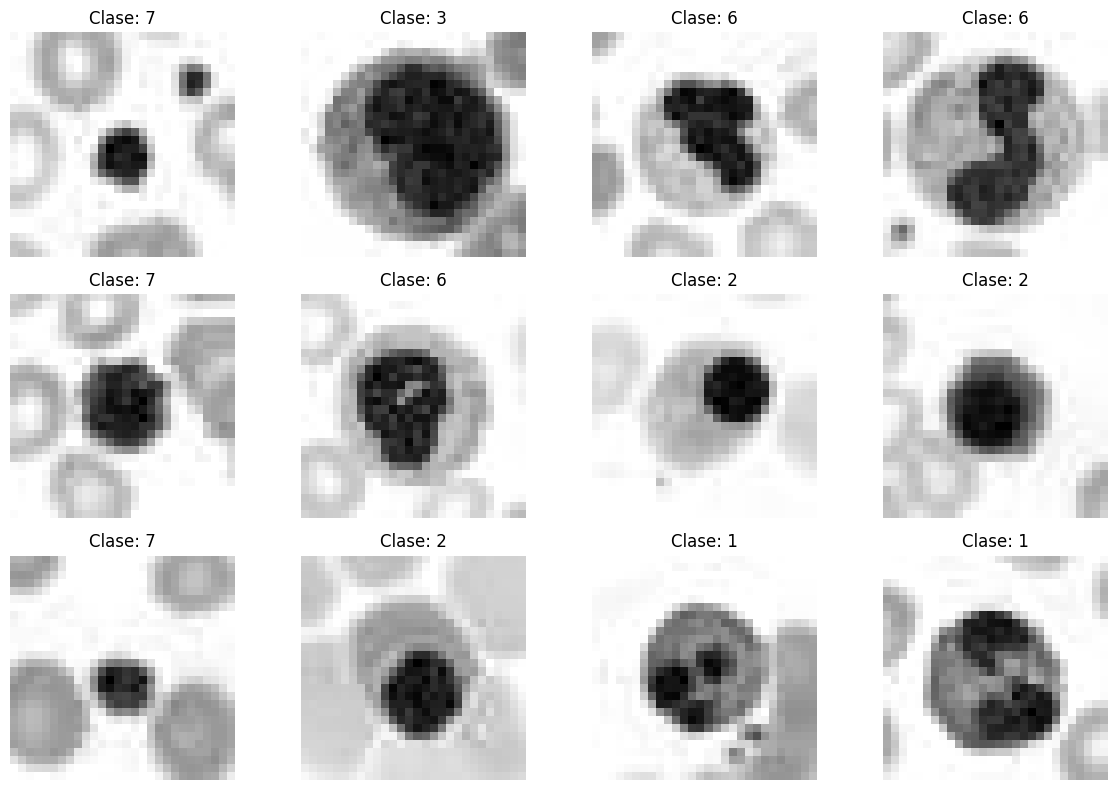

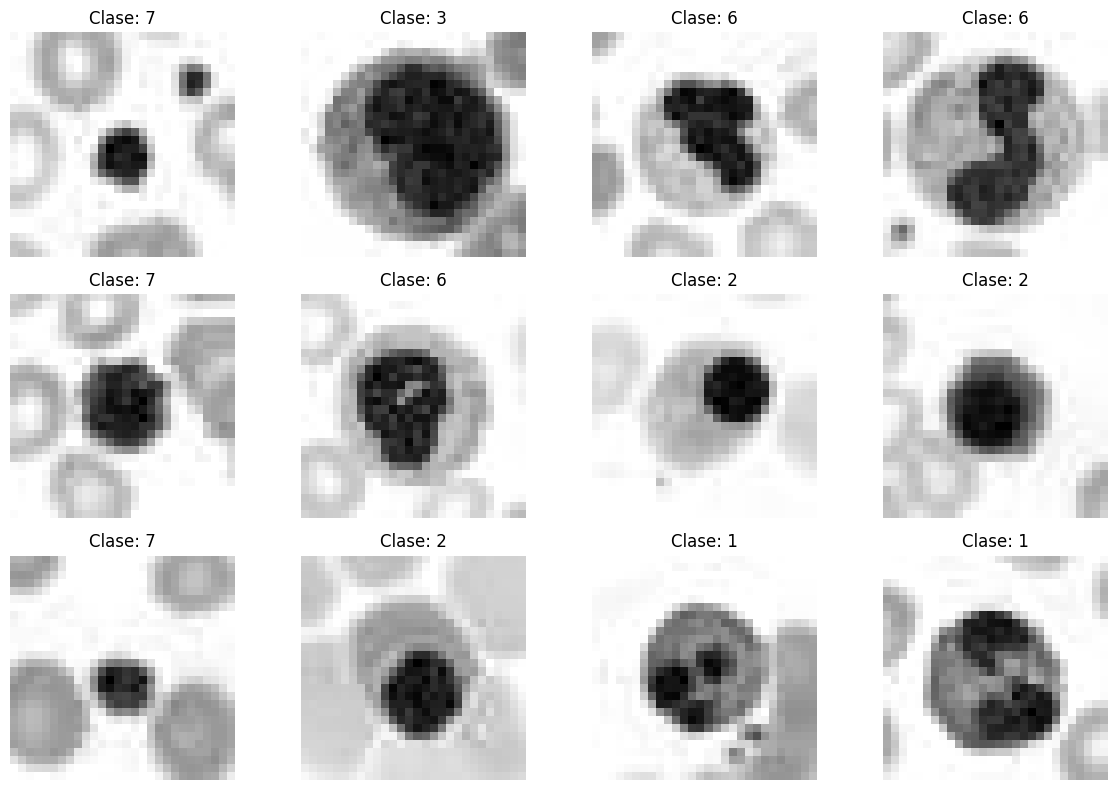

In [18]:
import matplotlib.pyplot as plt


def show_batch(dataset, n=12):
    plt.figure(figsize=(12, 8))

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)

        img = x[0]

        if img.ndim == 2:
            plt.imshow(img, cmap="gray")

        elif img.ndim == 3:
            img = img.permute(1, 2, 0)
            plt.imshow(img)

        plt.title(f"Clase: {y.item()}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_batch(train_dataset, n=12)
show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [20]:
batch_size = 128 # PROCESAR 128 IMÁGENES A LA VEZ

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True) # ORGANIZAR EN GRUPOS DE 128 IMÁGENES
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)    # PIN_MEMORY=TRUE HACE MEJOR TRANSF ENTRE GPU Y CPU
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape # 128 IMG DE 28X28; 128 IMG, 1 ETQ POR IMG


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [69]:
# REALIZAR ANALISIS CAPA POR CAPA
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"]) # DETERMINAR CUÁNTAS CLASES EXISTEN

class SimpleCNN(nn.Module): # CREAR LA RED NEURONAL CONVOLUCIONAL
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # PRIMERA CONVOLUCIÓN DE [128, 3, 28, 28] A [128, 16, 14, 14]
            nn.ReLU(),                                  # FUNCIÓN DE ACTIVACIÓN RELU
            nn.MaxPool2d(2),                            # REDUCIR Y CONSERVAR CARAC MÁS RELEVANTES

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # SEGUNDA CONVOLUCIÓN A [128, 32, 7, 7]
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # TERCERA CAPA A [128, 64, 1, 1]
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(  # CONVERTIR A PREDICCIÓN FINAL
            nn.Flatten(),                 # CONVERTIR A [128, 64]
            nn.Linear(64, num_classes)    # ESTA CAPA REALIZA LA CLASIFICACIÓN
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class CNN_BN_Dropout(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # DE [128, 3, 28, 28] A [128, 32, 14, 14]
            nn.BatchNorm2d(32),                           # Normalizar activaciones
            nn.ReLU(),                                    # RELU
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # A [128, 64, 7, 7]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # A [128, 128, 1, 1]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),                              # DESACTIVAR ALEATORIAMENTE 50% DE LAS NEURONAS
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = CNN_BN_Dropout(num_classes=num_classes).to(device) # CREAR EL BENDITO MODELO
model_scratch


CNN_BN_Dropout(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=128, out_features=8, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [77]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:

        # Pasar imágenes y etiquetas al dispositivo
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        # Obtener las predicciones del modelo
        logits = model(x)

        # Convertir logits a probabilidades
        probs = torch.softmax(logits, dim=1)

        # Elegir la clase con mayor probabilidad
        preds = torch.argmax(probs, dim=1)

        # Guardar resultados
        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    # Unir todos los batches
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    # Accuracy
    acc = accuracy_score(y_true, y_pred)

    # AUC para las 8 clases
    auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion): # LOG EXACTITUD... VER MÁS
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        loss = criterion(logits, y)

        losses.append(loss.item())

    return float(np.mean(losses))


In [78]:
print("num_classes =", num_classes)
print("labels =", info["label"])

num_classes = 8
labels = {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [79]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-5)  # CAMBIADO DE 10^-3 A 10^-5

epochs = 32  # HACER UNA ANÁLISIS DE 8 ÉPOCAS
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []} # PÉRDIDA, PRECISIÓN, CLASIFICACIÓN

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model_scratch, val_loader, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | "f"train_loss={train_loss:.4f} | "f"val_loss={val_loss:.4f} | "f"val_acc={val_acc:.4f} | "f"val_auc={val_auc:.4f}")
# IDEA: DISMINUIR PÉRDIDA, AUMENTAR EXACTITUD


Epoch 01 | train_loss=0.7822 | val_loss=0.7246 | val_acc=0.8061 | val_auc=0.9722
Epoch 02 | train_loss=0.7737 | val_loss=0.7127 | val_acc=0.8072 | val_auc=0.9724
Epoch 03 | train_loss=0.7600 | val_loss=0.7095 | val_acc=0.8143 | val_auc=0.9729
Epoch 04 | train_loss=0.7519 | val_loss=0.6954 | val_acc=0.8207 | val_auc=0.9734
Epoch 05 | train_loss=0.7410 | val_loss=0.6874 | val_acc=0.8207 | val_auc=0.9736
Epoch 06 | train_loss=0.7293 | val_loss=0.6782 | val_acc=0.8224 | val_auc=0.9740
Epoch 07 | train_loss=0.7218 | val_loss=0.6664 | val_acc=0.8259 | val_auc=0.9742
Epoch 08 | train_loss=0.7167 | val_loss=0.6606 | val_acc=0.8283 | val_auc=0.9749
Epoch 09 | train_loss=0.7085 | val_loss=0.6507 | val_acc=0.8283 | val_auc=0.9750
Epoch 10 | train_loss=0.6982 | val_loss=0.6433 | val_acc=0.8312 | val_auc=0.9753
Epoch 11 | train_loss=0.6895 | val_loss=0.6349 | val_acc=0.8318 | val_auc=0.9755
Epoch 12 | train_loss=0.6843 | val_loss=0.6257 | val_acc=0.8335 | val_auc=0.9759
Epoch 13 | train_loss=0.6729

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


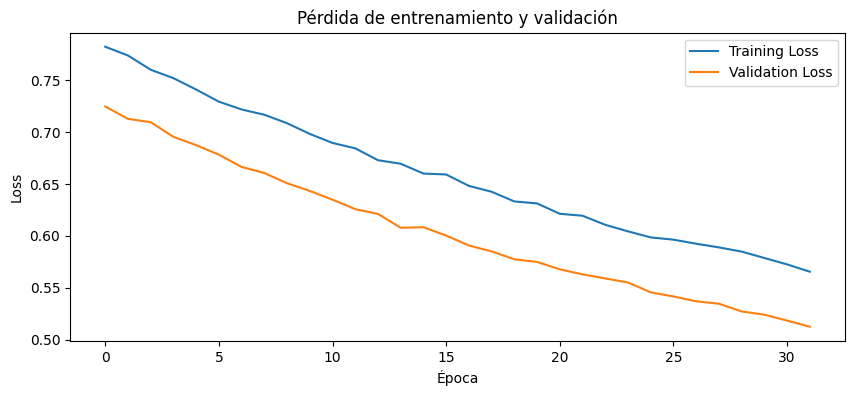

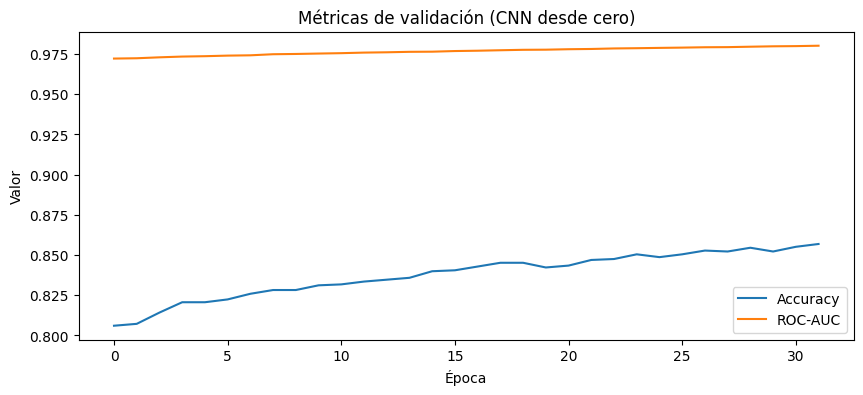

{'train_loss': [0.7822089322069858,
  0.7737458563865499,
  0.760030709682627,
  0.751923347407199,
  0.7409705088493672,
  0.7292670588544075,
  0.7217783147984362,
  0.7166663180006311,
  0.7085240128192496,
  0.6982179943551409,
  0.689507064033062,
  0.6843430571099545,
  0.6728747988000829,
  0.6694833344601571,
  0.6600396899466819,
  0.6591430217661756,
  0.6481666552259567,
  0.6425085391135926,
  0.6331895526419294,
  0.6312883325079655,
  0.6212828749037803,
  0.6194198886130718,
  0.6106853370970868,
  0.6043683731175483,
  0.598538671719267,
  0.596357414380033,
  0.5924514278452447,
  0.5889274341628906,
  0.5848706519984185,
  0.5787137937038502,
  0.5725438572624897,
  0.5654849546386841],
 'val_loss': [0.7245910891464779,
  0.7127395783151899,
  0.7094956338405609,
  0.6953510642051697,
  0.6873673583780017,
  0.6782218643597194,
  0.666428165776389,
  0.6605554606233325,
  0.650698333978653,
  0.6432572475501469,
  0.6348665484360286,
  0.6257332307951791,
  0.62117228

In [102]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Training Loss")
plt.plot(history_scratch["val_loss"], label="Validation Loss")
plt.title("Pérdida de entrenamiento y validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

history_scratch


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [82]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8527
Test ROC-AUC:  0.9788

              precision    recall  f1-score   support

           0     0.7742    0.5902    0.6698       244
           1     0.9527    0.9679    0.9603       624
           2     0.9247    0.8682    0.8955       311
           3     0.6176    0.7893    0.6929       579
           4     0.8465    0.7942    0.8195       243
           5     0.8333    0.4577    0.5909       284
           6     0.9154    0.9745    0.9440       666
           7     0.9874    1.0000    0.9937       470

    accuracy                         0.8527      3421
   macro avg     0.8565    0.8053    0.8208      3421
weighted avg     0.8607    0.8527    0.8492      3421



array([[144,   5,   1,  71,  16,   7,   0,   0],
       [  2, 604,   0,   7,   1,   2,   8,   0],
       [  2,   1, 270,  18,   6,   0,   8,   6],
       [ 27,  20,   8, 457,  10,  16,  41,   0],
       [ 10,   1,   9,  29, 193,   1,   0,   0],
       [  1,   0,   2, 146,   2, 130,   3,   0],
       [  0,   3,   2,  12,   0,   0, 649,   0],
       [  0,   0,   0,   0,   0,   0,   0, 470]])

## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [85]:
transform_aug = T.Compose([ # APLICAR PEQUEÑAS ROTACIONES Y TRANSLACIONES SUAVES, PARA AUMENTAR COMPLEJIDAD
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [88]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 16    # MUESTRA DE 6 ÉPOCAS
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=1.9222 | val_acc=0.4246 | val_auc=0.8005
Epoch 02 | train_loss=1.3832 | val_acc=0.4141 | val_auc=0.8291
Epoch 03 | train_loss=1.2724 | val_acc=0.4836 | val_auc=0.8769
Epoch 04 | train_loss=1.2020 | val_acc=0.6162 | val_auc=0.9025
Epoch 05 | train_loss=1.1003 | val_acc=0.6349 | val_auc=0.9215
Epoch 06 | train_loss=1.0121 | val_acc=0.6805 | val_auc=0.9327
Epoch 07 | train_loss=0.9339 | val_acc=0.6606 | val_auc=0.9346
Epoch 08 | train_loss=0.8955 | val_acc=0.6706 | val_auc=0.9395
Epoch 09 | train_loss=0.8687 | val_acc=0.6425 | val_auc=0.9378
Epoch 10 | train_loss=0.8412 | val_acc=0.6822 | val_auc=0.9426
Epoch 11 | train_loss=0.8250 | val_acc=0.7114 | val_auc=0.9483
Epoch 12 | train_loss=0.7959 | val_acc=0.6963 | val_auc=0.9481
Epoch 13 | train_loss=0.7660 | val_acc=0.7296 | val_auc=0.9552
Epoch 14 | train_loss=0.7265 | val_acc=0.7634 | val_auc=0.9610
Epoch 15 | train_loss=0.6895 | val_acc=0.7354 | val_auc=0.9584
Epoch 16 | train_loss=0.6601 | val_acc=0.7745 | val_auc

### 6.1. Comparación rápida


In [89]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")
# NO AUMENTA EN EXACTITUD, VER AUC.... NO CAMBIÓ MUCHO.. VER


Sin augmentation  | test_acc=0.8527 | test_auc=0.9788
Con augmentation  | test_acc=0.7644 | test_auc=0.9597


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [91]:
# REUTILIZAR UN MODELO ENTRENADO CON UN DATASET MÁS GRANDE
import torchvision.models as models

transform_tl_train = T.Compose([ # APLICAR RESNET? VER... 3
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    #T.Lambda(lambda x: x.repeat(3, 1, 1)) # CONVERSIÓN DE B/W A COLOR
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    #T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [92]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # UTILIZAR MODELO RESNET
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device) # MUEVE A CPU O GPU

for name, param in resnet.named_parameters(): # NO CAMBIAR RESNET PREENTRENADA?
    param.requires_grad = False

for param in resnet.fc.parameters(): # PERO SI CLASIFICAR ESTAS IMÁGENES?
    param.requires_grad = True

resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [93]:
x, y = next(iter(train_loader_tl))

print("Forma de x:", x.shape)
print("Forma de y:", y.shape)

Forma de x: torch.Size([64, 3, 224, 224])
Forma de y: torch.Size([64, 1])


In [94]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=1.0267 | val_acc=0.7588 | val_auc=0.9653
Stage1 Epoch 02 | train_loss=0.6354 | val_acc=0.7845 | val_auc=0.9721
Stage1 Epoch 03 | train_loss=0.5547 | val_acc=0.7944 | val_auc=0.9738
Stage1 Epoch 04 | train_loss=0.5192 | val_acc=0.8137 | val_auc=0.9767


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [95]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [96]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.3230 | val_acc=0.8989 | val_auc=0.9935
Stage2 Epoch 02 | train_loss=0.1863 | val_acc=0.9165 | val_auc=0.9953
Stage2 Epoch 03 | train_loss=0.1360 | val_acc=0.9346 | val_auc=0.9963
Stage2 Epoch 04 | train_loss=0.1075 | val_acc=0.9398 | val_auc=0.9969


### 7.3. Evaluación en test del modelo con transfer learning


In [97]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.9266 | test_auc=0.9957

              precision    recall  f1-score   support

           0     0.9838    0.7459    0.8485       244
           1     0.9808    0.9840    0.9824       624
           2     0.9556    0.9003    0.9272       311
           3     0.7738    0.9275    0.8437       579
           4     0.9137    0.9588    0.9357       243
           5     0.9224    0.7958    0.8544       284
           6     0.9721    0.9429    0.9573       666
           7     0.9853    1.0000    0.9926       470

    accuracy                         0.9266      3421
   macro avg     0.9360    0.9069    0.9177      3421
weighted avg     0.9330    0.9266    0.9269      3421



array([[182,   2,   0,  48,   5,   6,   1,   0],
       [  0, 614,   0,   5,   0,   0,   5,   0],
       [  0,   0, 280,  17,   5,   0,   2,   7],
       [  3,   4,   7, 537,   7,  11,  10,   0],
       [  0,   0,   3,   6, 233,   1,   0,   0],
       [  0,   0,   2,  52,   4, 226,   0,   0],
       [  0,   6,   1,  29,   1,   1, 628,   0],
       [  0,   0,   0,   0,   0,   0,   0, 470]])

### 7.4. Comparación global (resumen)


In [98]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8527 | auc=0.9788
CNN desde cero (con aug)  | acc=0.7644 | auc=0.9597
Transfer learning (ResNet) | acc=0.9266 | auc=0.9957


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [99]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


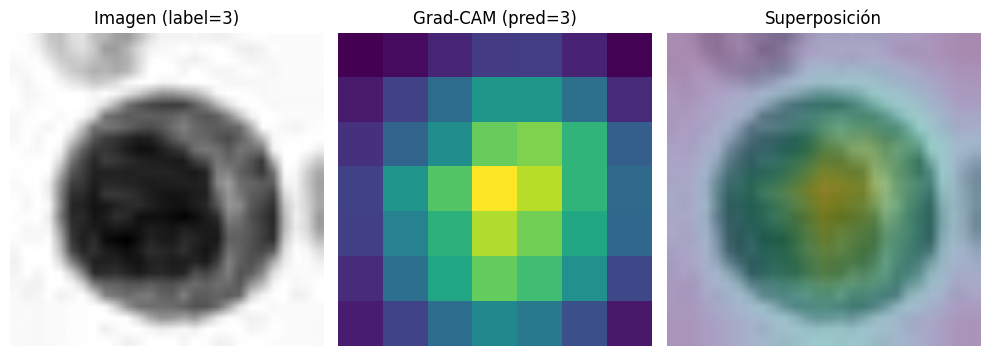

In [100]:
import cv2

idx = 45
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)
cam2 = cv2.resize(cam, (224, 224))
img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)

plt.imshow(cam2, alpha=0.9)
plt.imshow(img, cmap="gray", alpha=0.5)

plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [101]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros. [Ver 5]
- Se añadió Dropout y Batchnorm.

2) Experimenta con learning rate y scheduler. [Ver 5.2]
- Learning cambiado de 10^-3 a 10^-5.

3) Analiza el impacto de diferentes aumentos de datos. [Ver 6.1]
- Empeoró los resultados, posiblemente debido a que las imágenes son sensibles a las alteraciones.


4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline. [Ver 3]
- Cambiado a bloodmnist

5) Implementa calibración de probabilidades y analiza curvas ROC. [Ver 5.3]
- En las curvas ROC muestra capacidad de discriminación alta, aunque éste no mejora mucho en las 32 épocas.
- El modelo sigue aprendiendo, puesto a que cada vez aumenta más su precisión, pero no considerablemente.
- En las curvas de pérdidas de entrenamiento y validación muestran una misma tendencia, sin picos. No parece haber overfitting.